In [2]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


In [3]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

In [4]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

In [5]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


In [6]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


In [7]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


In [8]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import random

# Simulate low label regime
# Start with 5 labeled cultivars, add one at a time
# Evaluate LOCO performance at each step

# Fix random seed for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

# Apply best preprocessing (SG + SNV)
X_pre = snv(savitzky_golay_smooth(X))

# Build cultivar level data
# Each cultivar has one mean spectrum and one cysteine label
cultivar_mean_spectra = {}
cultivar_labels       = {}

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    if spectra:
        mean_spectrum = np.mean([s[1] for s in spectra], axis=0)
        cultivar_mean_spectra[folder_name] = mean_spectrum
        cultivar_labels[folder_name]       = meta['cys']

print(f"Total cultivars: {len(cultivar_mean_spectra)}")
print(f"Cysteine range: {min(cultivar_labels.values()):.4f} to {max(cultivar_labels.values()):.4f}")

Total cultivars: 20
Cysteine range: 0.3120 to 0.3732


In [9]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, batch_size=32, lr=1e-4):

    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val).to(device)

    dataset   = TensorDataset(X_tr, y_tr)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader),
                    epochs=epochs)

    model.to(device)

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_weights)
    return model, train_losses, val_losses

print("train_model defined!")

train_model defined!


In [10]:
class CNN1D(nn.Module):
    def __init__(self, input_size=1530):
        super(CNN1D, self).__init__()

        # ── Convolutional blocks ──
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 4
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Calculate flattened size after conv blocks
        # 1530 → /2 → /2 → /2 → /2 = 1530/16 = 95
        self.flat_size = 128 * (input_size // 16)

        # ── Fully connected layers ──
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)   # output = single cysteine value
        )

    def forward(self, x):
        # x shape: (batch, 1530)
        x = x.unsqueeze(1)          # → (batch, 1, 1530) for Conv1d
        x = self.conv_blocks(x)     # → (batch, 128, 95)
        x = x.view(x.size(0), -1)  # → flatten: (batch, 12160)
        x = self.fc_layers(x)       # → (batch, 1)
        return x.squeeze(1)         # → (batch,)

# Test the architecture
model_test = CNN1D(input_size=1530)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

CNN1D(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): 

In [11]:
def get_all_spectra_for_cultivar(folder_name, X_preprocessed):
    """Get all preprocessed spectra for a cultivar"""
    start = cultivar_names.index(folder_name) * 324
    end   = start + 324
    return X_preprocessed[start:end]

def train_committee(labeled_cultivars, X_preprocessed, val_holdout=True):
    """Train PLSR, SVR and CNN on labeled cultivars.
    CNN checkpoint selection uses a cultivar held out of the labeled
    set for validation, never train-on-train, and never the test pool."""

    # cultivar-level val split: hold out 1 labeled cultivar for CNN val
    if val_holdout and len(labeled_cultivars) >= 4:
        val_cult   = labeled_cultivars[-1]          # deterministic, seeded upstream
        train_cults = labeled_cultivars[:-1]
    else:
        val_cult   = None
        train_cults = labeled_cultivars

    X_train, y_train = [], []
    for cult in train_cults:
        spectra = get_all_spectra_for_cultivar(cult, X_preprocessed)
        X_train.extend(spectra)
        y_train.extend([cultivar_labels[cult]] * len(spectra))
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    if val_cult is not None:
        X_val = get_all_spectra_for_cultivar(val_cult, X_preprocessed)
        y_val = np.array([cultivar_labels[val_cult]] * len(X_val))
    else:
        X_val, y_val = X_train, y_train   # fallback only for tiny sets

    # PLSR (fit on train cultivars only)
    plsr = PLSRegression(n_components=min(18, len(train_cults) - 1))
    plsr.fit(X_train, y_train)

    # SVR
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    svr = SVR(kernel='rbf', C=100, epsilon=0.001, gamma='auto')
    svr.fit(X_scaled, y_train)

    # CNN — checkpoint chosen on held-out cultivar, not train
    torch.manual_seed(42)
    cnn = CNN1D(input_size=1530).to(device)
    cnn, _, _ = train_model(
        model=cnn,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        epochs=50, batch_size=32, lr=1e-4
    )

    return plsr, svr, scaler, cnn

def predict_committee(plsr, svr, scaler, cnn, X_test):
    """Get predictions from all three models"""
    # PLSR prediction
    plsr_pred = plsr.predict(X_test).flatten()
    
    # SVR prediction
    X_scaled = scaler.transform(X_test)
    svr_pred  = svr.predict(X_scaled)
    
    # CNN prediction
    cnn.eval()
    with torch.no_grad():
        cnn_pred = cnn(
            torch.FloatTensor(X_test).to(device)
        ).cpu().numpy()
    
    return plsr_pred, svr_pred, cnn_pred

def compute_disagreement(plsr_pred, svr_pred, cnn_pred):
    """Compute disagreement as std of predictions across models"""
    preds = np.stack([plsr_pred, svr_pred, cnn_pred], axis=0)
    return np.std(preds, axis=0).mean()  # mean std across all spectra

def evaluate_loco(labeled_cultivars, X_preprocessed):
    """Evaluate LOCO performance on labeled cultivars only"""
    if len(labeled_cultivars) < 3:
        return None, None, None
    
    all_true, all_pred = [], []
    
    for held_out in labeled_cultivars:
        train_set = [c for c in labeled_cultivars if c != held_out]
        
        X_tr, y_tr = [], []
        for cult in train_set:
            spectra = get_all_spectra_for_cultivar(cult, X_preprocessed)
            X_tr.extend(spectra)
            y_tr.extend([cultivar_labels[cult]] * len(spectra))
        
        X_te = get_all_spectra_for_cultivar(held_out, X_preprocessed)
        y_te = [cultivar_labels[held_out]] * len(X_te)
        
        plsr = PLSRegression(n_components=min(10, len(train_set)-1))
        plsr.fit(np.array(X_tr), np.array(y_tr))
        pred = plsr.predict(np.array(X_te)).flatten()
        
        all_true.extend(y_te)
        all_pred.extend(pred)
    
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    
    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    r2   = r2_score(all_true, all_pred)
    rpd  = all_true.std() / rmse
    
    return rmse, r2, rpd

print("Helper functions defined!")

Helper functions defined!


In [12]:
# Start with 5 random labeled cultivars
all_cultivar_names  = list(CULTIVARS.keys())
initial_labeled     = random.sample(all_cultivar_names, 5)
labeled_set         = initial_labeled.copy()
unlabeled_set       = [c for c in all_cultivar_names if c not in labeled_set]

print(f"Initial labeled set ({len(labeled_set)} cultivars):")
for c in labeled_set:
    print(f"  {CULTIVARS[c]['label']} — cysteine: {cultivar_labels[c]:.4f}")

# Track results at each step
qbc_results = []

# Evaluate initial performance
rmse, r2, rpd = evaluate_loco(labeled_set, X_pre)
qbc_results.append({
    "step":          0,
    "n_labeled":     len(labeled_set),
    "added":         "Initial random selection",
    "labeled":       labeled_set.copy(),
    "rmse":          rmse,
    "r2":            r2,
    "rpd":           rpd,
    "disagreements": {}
})
print(f"\nInitial LOCO — RMSE: {rmse:.4f}  R²: {r2:.4f}  RPD: {rpd:.4f}")

# Active learning loop — add one cultivar at a time
for step in range(len(unlabeled_set)):
    print(f"\n{'='*50}")
    print(f"Step {step+1} — Labeled: {len(labeled_set)}, Unlabeled: {len(unlabeled_set)}")
    print(f"{'='*50}")

    # Train committee on current labeled set
    print("Training committee (PLSR + SVR + CNN)...")
    plsr, svr, scaler, cnn = train_committee(labeled_set, X_pre)

    # Compute disagreement for each unlabeled cultivar
    disagreements = {}
    for cult in unlabeled_set:
        X_cult = get_all_spectra_for_cultivar(cult, X_pre)
        plsr_pred, svr_pred, cnn_pred = predict_committee(
            plsr, svr, scaler, cnn, X_cult
        )
        disagreements[cult] = compute_disagreement(
            plsr_pred, svr_pred, cnn_pred
        )
        print(f"  {CULTIVARS[cult]['label']:20s} disagreement: {disagreements[cult]:.5f}")

    # Select cultivar with highest disagreement
    next_cultivar = max(disagreements, key=disagreements.get)
    print(f"\nSelected: {CULTIVARS[next_cultivar]['label']} "
          f"(disagreement: {disagreements[next_cultivar]:.5f})")

    # Add to labeled set
    labeled_set.append(next_cultivar)
    unlabeled_set.remove(next_cultivar)

    # Evaluate LOCO on new labeled set
    rmse, r2, rpd = evaluate_loco(labeled_set, X_pre)
    print(f"LOCO — RMSE: {rmse:.4f}  R²: {r2:.4f}  RPD: {rpd:.4f}")

    qbc_results.append({
        "step":          step + 1,
        "n_labeled":     len(labeled_set),
        "added":         CULTIVARS[next_cultivar]['label'],
        "labeled":       labeled_set.copy(),
        "rmse":          rmse,
        "r2":            r2,
        "rpd":           rpd,
        "disagreements": disagreements
    })

print("\n QBC ACTIVE LEARNING COMPLETE!")

Initial labeled set (5 cultivars):
  CDC Amarillo — cysteine: 0.3589
  AAC Chrome — cysteine: 0.3172
  CDC Greenwater — cysteine: 0.3464
  CDC Golden — cysteine: 0.3591
  CDC Spruce — cysteine: 0.3457

Initial LOCO — RMSE: 0.0256  R²: -1.8076  RPD: 0.5968

Step 1 — Labeled: 5, Unlabeled: 15
Training committee (PLSR + SVR + CNN)...
  AAC Lacombe          disagreement: 0.00449
  AAC Liscard          disagreement: 0.00963
  CDC Athabasca        disagreement: 0.00434
  CDC Canary           disagreement: 0.00660
  CDC Dakota           disagreement: 0.00782
  CDC Inca             disagreement: 0.00387
  CDC Jasper           disagreement: 0.00585
  CDC Lewochko         disagreement: 0.00711
  CDC Meadow           disagreement: 0.00704
  CDC Patrick          disagreement: 0.00587
  CDC Saffron          disagreement: 0.00906
  CDC Spectrum         disagreement: 0.00714
  CDC Striker          disagreement: 0.00519
  CDC Tetris           disagreement: 0.00350
  Redbat 88            disagreement: 

seed 1/30 done
seed 2/30 done
seed 3/30 done
seed 4/30 done
seed 5/30 done
seed 6/30 done
seed 7/30 done
seed 8/30 done
seed 9/30 done
seed 10/30 done
seed 11/30 done
seed 12/30 done
seed 13/30 done
seed 14/30 done
seed 15/30 done
seed 16/30 done
seed 17/30 done
seed 18/30 done
seed 19/30 done
seed 20/30 done
seed 21/30 done
seed 22/30 done
seed 23/30 done
seed 24/30 done
seed 25/30 done
seed 26/30 done
seed 27/30 done
seed 28/30 done
seed 29/30 done
seed 30/30 done
n= 5  R2 -1.380 ± 1.321   RMSE 0.0215
n= 6  R2 -1.369 ± 1.047   RMSE 0.0219
n= 7  R2 -1.474 ± 1.201   RMSE 0.0235
n= 8  R2 -1.381 ± 1.184   RMSE 0.0235
n= 9  R2 -1.248 ± 0.933   RMSE 0.0232
n=10  R2 -1.450 ± 1.154   RMSE 0.0241
n=11  R2 -1.429 ± 1.251   RMSE 0.0241
n=12  R2 -1.451 ± 1.152   RMSE 0.0242
n=13  R2 -1.197 ± 0.842   RMSE 0.0231
n=14  R2 -1.124 ± 0.711   RMSE 0.0228
n=15  R2 -1.082 ± 0.652   RMSE 0.0226
n=16  R2 -0.938 ± 0.521   RMSE 0.0222
n=17  R2 -0.905 ± 0.429   RMSE 0.0221
n=18  R2 -0.887 ± 0.457   RMSE 0.02

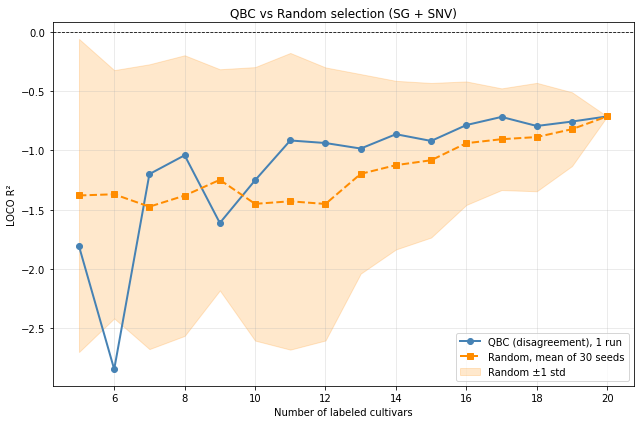


=== QBC vs random band ===
n= 5  QBC -1.808   random -1.380 ± 1.321   → inside noise
n= 6  QBC -2.846   random -1.369 ± 1.047   → below band
n= 7  QBC -1.199   random -1.474 ± 1.201   → inside noise
n= 8  QBC -1.040   random -1.381 ± 1.184   → inside noise
n= 9  QBC -1.612   random -1.248 ± 0.933   → inside noise
n=10  QBC -1.252   random -1.450 ± 1.154   → inside noise
n=11  QBC -0.916   random -1.429 ± 1.251   → inside noise
n=12  QBC -0.937   random -1.451 ± 1.152   → inside noise
n=13  QBC -0.984   random -1.197 ± 0.842   → inside noise
n=14  QBC -0.863   random -1.124 ± 0.711   → inside noise
n=15  QBC -0.920   random -1.082 ± 0.652   → inside noise
n=16  QBC -0.786   random -0.938 ± 0.521   → inside noise
n=17  QBC -0.717   random -0.905 ± 0.429   → inside noise
n=18  QBC -0.793   random -0.887 ± 0.457   → inside noise
n=19  QBC -0.756   random -0.820 ± 0.311   → inside noise
n=20  QBC -0.713   random -0.713 ± 0.000   → inside noise


In [13]:
# Random baseline averaged over 30 seeds so the band is trustworthy
# (matches the 30-seed protocol from the iGS experiment)
N_SEEDS = 30
all_cultivar_names = list(CULTIVARS.keys())

# n_labeled from 5 up to 20, collect r2/rmse per seed
random_by_n = {n: {"r2": [], "rmse": []} for n in range(5, len(all_cultivar_names) + 1)}

for seed in range(N_SEEDS):
    rng = random.Random(seed)
    order = rng.sample(all_cultivar_names, len(all_cultivar_names))
    for n in range(5, len(all_cultivar_names) + 1):
        rmse, r2, rpd = evaluate_loco(order[:n], X_pre)
        if r2 is not None:
            random_by_n[n]["r2"].append(r2)
            random_by_n[n]["rmse"].append(rmse)
    print(f"seed {seed+1}/{N_SEEDS} done")

random_results = []
for n in sorted(random_by_n):
    r2s   = np.array(random_by_n[n]["r2"])
    rmses = np.array(random_by_n[n]["rmse"])
    random_results.append({
        "n_labeled": n,
        "r2":       r2s.mean(),   "r2_std":   r2s.std(),
        "rmse":     rmses.mean(), "rmse_std": rmses.std(),
    })
    print(f"n={n:2d}  R2 {r2s.mean():+.3f} ± {r2s.std():.3f}   RMSE {rmses.mean():.4f}")

qbc_n    = [r['n_labeled'] for r in qbc_results if r['r2'] is not None]
qbc_r2   = [r['r2']        for r in qbc_results if r['r2'] is not None]

rand_n     = [r['n_labeled'] for r in random_results]
rand_r2     = [r['r2']       for r in random_results]
rand_r2_std = [r['r2_std']   for r in random_results]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(qbc_n, qbc_r2, 'o-', color='steelblue', linewidth=2,
        markersize=6, label='QBC (disagreement), 1 run')
ax.plot(rand_n, rand_r2, 's--', color='darkorange', linewidth=2,
        markersize=6, label='Random, mean of 30 seeds')
ax.fill_between(rand_n,
                np.array(rand_r2) - np.array(rand_r2_std),
                np.array(rand_r2) + np.array(rand_r2_std),
                color='darkorange', alpha=0.2, label='Random ±1 std')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Number of labeled cultivars")
ax.set_ylabel("LOCO R²")
ax.set_title("QBC vs Random selection (SG + SNV)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("QBC_vs_random_30seed.png", dpi=150, bbox_inches='tight')
plt.show()

# Honest reading: is QBC inside or outside the random band at each n?
print("\n=== QBC vs random band ===")
for r in random_results:
    n = r['n_labeled']
    q = next((x['r2'] for x in qbc_results if x['n_labeled'] == n), None)
    if q is None:
        continue
    lo, hi = r['r2'] - r['r2_std'], r['r2'] + r['r2_std']
    verdict = "above band" if q > hi else ("below band" if q < lo else "inside noise")
    print(f"n={n:2d}  QBC {q:+.3f}   random {r['r2']:+.3f} ± {r['r2_std']:.3f}   → {verdict}")

In [18]:
import json


qbc_save = []
for r in qbc_results:
    qbc_save.append({
        "step":      r['step'],
        "n_labeled": r['n_labeled'],
        "added":     r['added'],
        "rmse":      r['rmse'],
        "r2":        r['r2'],
        "rpd":       r['rpd'],
        "labeled":   r['labeled']
    })

with open("qbc_results.json", "w") as f:
    json.dump(qbc_save, f, indent=2)

random_save = []
for r in random_results:
    random_save.append({
        "n_labeled": r['n_labeled'],
        "rmse":      r['rmse'],
        "rmse_std":  r['rmse_std'],
        "r2":        r['r2'],
        "r2_std":    r['r2_std'],
    })

with open("random_results.json", "w") as f:
    json.dump(random_save, f, indent=2)

print("Results saved to qbc_results.json and random_results.json")

Results saved to qbc_results.json and random_results.json


In [19]:
# Which cultivars did QBC select first vs random?
print("=== QBC Selection Order ===")
print(f"{'Step':<6} {'Added Cultivar':<25} {'Cysteine':>10} {'N Labeled':>10} {'LOCO R²':>10} {'LOCO RMSE':>12}")
print("-"*75)
for r in qbc_results:
    cys = cultivar_labels.get(
        next((k for k, v in CULTIVARS.items() 
              if v['label'] == r['added']), None), 0
    )
    r2_str = f"{r['r2']:.4f}"  if r['r2']   is not None else "N/A"
    rm_str = f"{r['rmse']:.4f}" if r['rmse'] is not None else "N/A"
    print(f"{r['step']:<6} {r['added']:<25} {cys:>10.4f} "
          f"{r['n_labeled']:>10} {r2_str:>10} {rm_str:>12}")

print("\n=== Random Selection Order ===")
print(f"{'N Labeled':>10} {'LOCO R²':>10} {'LOCO RMSE':>12}")
print("-"*35)
for r in random_results:
    r2_str = f"{r['r2']:.4f}"  if r['r2']   is not None else "N/A"
    rm_str = f"{r['rmse']:.4f}" if r['rmse'] is not None else "N/A"
    print(f"{r['n_labeled']:>10} {r2_str:>10} {rm_str:>12}")

=== QBC Selection Order ===
Step   Added Cultivar              Cysteine  N Labeled    LOCO R²    LOCO RMSE
---------------------------------------------------------------------------
0      Initial random selection      0.0000          5    -1.8076       0.0256
1      AAC Liscard                   0.3254          6    -2.8460       0.0310
2      CDC Dakota                    0.3328          7    -1.1991       0.0222
3      CDC Saffron                   0.3468          8    -1.0404       0.0202
4      CDC Spectrum                  0.3732          9    -1.6117       0.0269
5      CDC Lewochko                  0.3413         10    -1.2517       0.0238
6      CDC Inca                      0.3653         11    -0.9156       0.0225
7      CDC Jasper                    0.3373         12    -0.9371       0.0219
8      CDC Meadow                    0.3120         13    -0.9838       0.0248
9      CDC Athabasca                 0.3412         14    -0.8627       0.0232
10     CDC Striker         

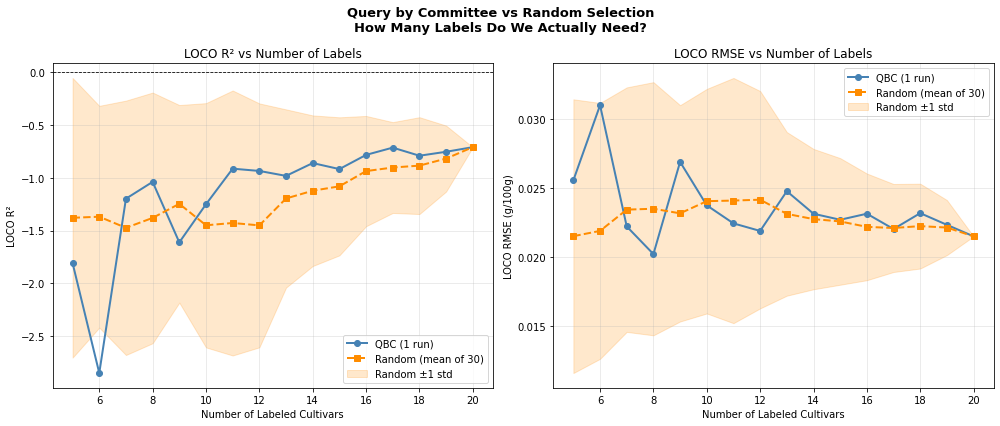


=== QBC vs random band ===
n= 5  QBC -1.808   random -1.380 ± 1.321   → inside noise
n= 6  QBC -2.846   random -1.369 ± 1.047   → below band
n= 7  QBC -1.199   random -1.474 ± 1.201   → inside noise
n= 8  QBC -1.040   random -1.381 ± 1.184   → inside noise
n= 9  QBC -1.612   random -1.248 ± 0.933   → inside noise
n=10  QBC -1.252   random -1.450 ± 1.154   → inside noise
n=11  QBC -0.916   random -1.429 ± 1.251   → inside noise
n=12  QBC -0.937   random -1.451 ± 1.152   → inside noise
n=13  QBC -0.984   random -1.197 ± 0.842   → inside noise
n=14  QBC -0.863   random -1.124 ± 0.711   → inside noise
n=15  QBC -0.920   random -1.082 ± 0.652   → inside noise
n=16  QBC -0.786   random -0.938 ± 0.521   → inside noise
n=17  QBC -0.717   random -0.905 ± 0.429   → inside noise
n=18  QBC -0.793   random -0.887 ± 0.457   → inside noise
n=19  QBC -0.756   random -0.820 ± 0.311   → inside noise
n=20  QBC -0.713   random -0.713 ± 0.000   → inside noise


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

qbc_n    = [r['n_labeled'] for r in qbc_results if r['r2'] is not None]
qbc_r2   = [r['r2']        for r in qbc_results if r['r2'] is not None]
qbc_rmse = [r['rmse']      for r in qbc_results if r['rmse'] is not None]

rand_n       = [r['n_labeled'] for r in random_results]
rand_r2      = [r['r2']        for r in random_results]
rand_r2_std  = [r['r2_std']    for r in random_results]
rand_rmse    = [r['rmse']      for r in random_results]
rand_rmse_std= [r['rmse_std']  for r in random_results]

# ── R² ──
ax1 = axes[0]
ax1.plot(qbc_n, qbc_r2, 'o-', color='steelblue', linewidth=2,
         markersize=6, label='QBC (1 run)')
ax1.plot(rand_n, rand_r2, 's--', color='darkorange', linewidth=2,
         markersize=6, label='Random (mean of 30)')
ax1.fill_between(rand_n,
                 np.array(rand_r2) - np.array(rand_r2_std),
                 np.array(rand_r2) + np.array(rand_r2_std),
                 color='darkorange', alpha=0.2, label='Random ±1 std')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel("Number of Labeled Cultivars")
ax1.set_ylabel("LOCO R²")
ax1.set_title("LOCO R² vs Number of Labels")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── RMSE ──
ax2 = axes[1]
ax2.plot(qbc_n, qbc_rmse, 'o-', color='steelblue', linewidth=2,
         markersize=6, label='QBC (1 run)')
ax2.plot(rand_n, rand_rmse, 's--', color='darkorange', linewidth=2,
         markersize=6, label='Random (mean of 30)')
ax2.fill_between(rand_n,
                 np.array(rand_rmse) - np.array(rand_rmse_std),
                 np.array(rand_rmse) + np.array(rand_rmse_std),
                 color='darkorange', alpha=0.2, label='Random ±1 std')
ax2.set_xlabel("Number of Labeled Cultivars")
ax2.set_ylabel("LOCO RMSE (g/100g)")
ax2.set_title("LOCO RMSE vs Number of Labels")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Query by Committee vs Random Selection\nHow Many Labels Do We Actually Need?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("QBC_vs_random_detailed.png", dpi=150, bbox_inches='tight')
plt.show()

# Honest reading: QBC vs random band at each label count
print("\n=== QBC vs random band ===")
for r in random_results:
    n = r['n_labeled']
    q = next((x['r2'] for x in qbc_results if x['n_labeled'] == n), None)
    if q is None:
        continue
    lo, hi = r['r2'] - r['r2_std'], r['r2'] + r['r2_std']
    verdict = "above band" if q > hi else ("below band" if q < lo else "inside noise")
    print(f"n={n:2d}  QBC {q:+.3f}   random {r['r2']:+.3f} ± {r['r2_std']:.3f}   → {verdict}")

In [16]:
# ============================================================
# HYBRID: disagreement × label-space coverage
# Novel criterion. QBC finds uncertain cultivars but clumps them
# at the high-cysteine end (the slide-29 blind spot). We add a
# coverage term that rewards filling gaps in the PREDICTED label
# range, so picks spread across cysteine instead of clustering.
# ============================================================

def predicted_cysteine(plsr, svr, scaler, cnn, cult, X_pre):
    """Committee mean prediction for a cultivar (one scalar)."""
    X_cult = get_all_spectra_for_cultivar(cult, X_pre)
    p, s, c = predict_committee(plsr, svr, scaler, cnn, X_cult)
    return float(np.mean([p.mean(), s.mean(), c.mean()]))

def coverage_gap(cand_pred, labeled_preds):
    """How far the candidate's predicted cysteine sits from the
    nearest already-labeled cultivar, in predicted-label space.
    Large gap = fills an empty region of the range = valuable."""
    if not labeled_preds:
        return 1.0
    return min(abs(cand_pred - lp) for lp in labeled_preds)

def run_hybrid(beta, X_pre, seed=42, init_n=5):
    """beta trades off the two forces on a 0..1 log scale:
       score = disagreement^(1-beta) * coverage_gap^beta
       beta=0  -> pure QBC (disagreement only)
       beta=1  -> pure label-space coverage
    """
    rng = random.Random(seed)
    labeled   = rng.sample(all_cultivar_names, init_n)
    unlabeled = [c for c in all_cultivar_names if c not in labeled]

    results = []
    rmse, r2, rpd = evaluate_loco(labeled, X_pre)
    results.append({"n_labeled": len(labeled), "r2": r2, "rmse": rmse, "added": "init"})

    while unlabeled:
        plsr, svr, scaler, cnn = train_committee(labeled, X_pre)

        labeled_preds = [predicted_cysteine(plsr, svr, scaler, cnn, c, X_pre)
                         for c in labeled]

        # normalise both terms to 0..1 across candidates so beta is meaningful
        disag, cover, preds = {}, {}, {}
        for cult in unlabeled:
            X_cult = get_all_spectra_for_cultivar(cult, X_pre)
            pp, sp, cp = predict_committee(plsr, svr, scaler, cnn, X_cult)
            disag[cult] = compute_disagreement(pp, sp, cp)
            preds[cult] = float(np.mean([pp.mean(), sp.mean(), cp.mean()]))
            cover[cult] = coverage_gap(preds[cult], labeled_preds)

        d_max = max(disag.values()) or 1.0
        c_max = max(cover.values()) or 1.0
        # +1e-9 avoids a zero term killing the product
        score = {c: ((disag[c]/d_max) + 1e-9)**(1-beta) *
                    ((cover[c]/c_max) + 1e-9)**beta
                 for c in unlabeled}

        nxt = max(score, key=score.get)
        labeled.append(nxt); unlabeled.remove(nxt)

        rmse, r2, rpd = evaluate_loco(labeled, X_pre)
        results.append({"n_labeled": len(labeled), "r2": r2, "rmse": rmse,
                        "added": CULTIVARS[nxt]['label']})
    return results

# sweep beta: 0 (pure QBC) → 1 (pure coverage), same seed as QBC/random
betas = [0.0, 0.25, 0.5, 0.75, 1.0]
hybrid_runs = {}
for b in betas:
    print(f"running beta={b} ...")
    hybrid_runs[b] = run_hybrid(b, X_pre, seed=42)

print("\n=== Hybrid vs random band, at planned budget n=10 ===")
rand10 = next(r for r in random_results if r['n_labeled'] == 10)
lo, hi = rand10['r2'] - rand10['r2_std'], rand10['r2'] + rand10['r2_std']
for b in betas:
    q = next(r['r2'] for r in hybrid_runs[b] if r['n_labeled'] == 10)
    verdict = "ABOVE band" if q > hi else ("below band" if q < lo else "inside noise")
    print(f"beta={b:<4}  R2 {q:+.3f}   random {rand10['r2']:+.3f} ± {rand10['r2_std']:.3f}  → {verdict}")

running beta=0.0 ...
running beta=0.25 ...
running beta=0.5 ...
running beta=0.75 ...
running beta=1.0 ...

=== Hybrid vs random band, at planned budget n=10 ===
beta=0.0   R2 -1.500   random -1.450 ± 1.154  → inside noise
beta=0.25  R2 -1.196   random -1.450 ± 1.154  → inside noise
beta=0.5   R2 -1.682   random -1.450 ± 1.154  → inside noise
beta=0.75  R2 -1.123   random -1.450 ± 1.154  → inside noise
beta=1.0   R2 -0.375   random -1.450 ± 1.154  → inside noise


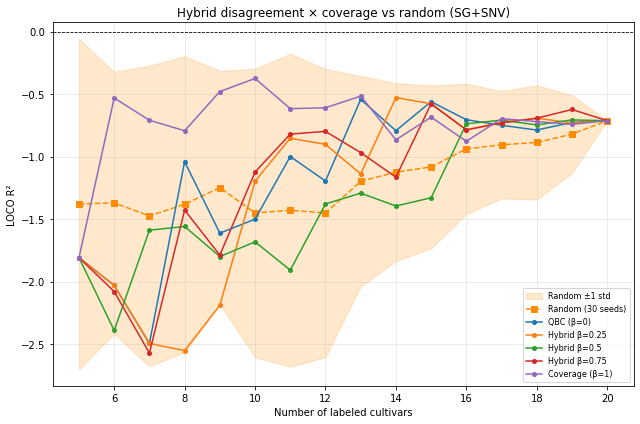

In [17]:
plt.figure(figsize=(9,6))
rn  = [r['n_labeled'] for r in random_results]
rr  = [r['r2'] for r in random_results]
rs  = [r['r2_std'] for r in random_results]
plt.fill_between(rn, np.array(rr)-np.array(rs), np.array(rr)+np.array(rs),
                 color='darkorange', alpha=0.2, label='Random ±1 std')
plt.plot(rn, rr, 's--', color='darkorange', label='Random (30 seeds)')
for b in betas:
    n  = [r['n_labeled'] for r in hybrid_runs[b]]
    r2 = [r['r2'] for r in hybrid_runs[b]]
    lbl = 'QBC (β=0)' if b==0 else ('Coverage (β=1)' if b==1 else f'Hybrid β={b}')
    plt.plot(n, r2, 'o-', linewidth=1.5, markersize=4, label=lbl)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Number of labeled cultivars"); plt.ylabel("LOCO R²")
plt.title("Hybrid disagreement × coverage vs random (SG+SNV)")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("hybrid_vs_random.png", dpi=150, bbox_inches='tight'); plt.show()